In [6]:
%pip install pandas numpy matplotlib seaborn corus pymorphy3 razdel nltk tqdm scikit-learn -q


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import lru_cache
import sklearn
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, confusion_matrix, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
import re
import corus
import pymorphy3
import razdel
import nltk
import tqdm

In [112]:
DATASET_SIZE = 100000
RANDOM_STATE = 42
MAX_FEATURES = 3000

In [ ]:
!curl -L -o 'https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz'

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0
100  502M  100  502M    0     0  2432k      0  0:03:31  0:03:31 --:--:-- 2327k0  0:03:17 2448k013k 0  2515k      0  0:03:24  0:00:54  0:02:30 2791k     0  0:03:23  0:01:05  0:02:18 1994k     0  2505k      0  0:03:25  0:01:14  0:02:11 1868k01:22  0:02:03 2730k02:40  0:00:54 2554k   0     0  2405k      0  0:03:34  0:03:14  0:00:20 3078k 0:03:16  0:00:16 3442k0     0  2430k      0  0:03:31  0:03:19  0:00:12 3431k


### EDA

In [ ]:
path = 'lenta-ru-news.csv.gz'
data = [item for i, item in enumerate(corus.load_lenta(path)) if i < DATASET_SIZE]
data[:5]

[LentaRecord(
     url='https://lenta.ru/news/2018/12/14/cancer/',
     title='Названы регионы России с\xa0самой высокой смертностью от\xa0рака',
     text='Вице-премьер по социальным вопросам Татьяна Голикова рассказала, в каких регионах России зафиксирована наиболее высокая смертность от рака, сообщает РИА Новости. По словам Голиковой, чаще всего онкологические заболевания становились причиной смерти в Псковской, Тверской, Тульской и Орловской областях, а также в Севастополе. Вице-премьер напомнила, что главные факторы смертности в России — рак и болезни системы кровообращения. В начале года стало известно, что смертность от онкологических заболеваний среди россиян снизилась впервые за три года. По данным Росстата, в 2017 году от рака умерли 289 тысяч человек. Это на 3,5 процента меньше, чем годом ранее.',
     topic='Россия',
     tags='Общество',
     date=None
 ),
 LentaRecord(
     url='https://lenta.ru/news/2018/12/15/doping/',
     title='Австрия не\xa0представила доказательств

In [68]:
df = pd.DataFrame([{'text': r.text, 'topic': r.topic} for r in data])
df.head()

,text,topic
0,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрийские правоохранительные органы не предс...,Спорт
2,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,С начала расследования российского вмешательст...,Мир
4,Хакерская группировка Anonymous опубликовала н...,Мир


In [69]:
df.isna().sum()

text     0
topic    0
dtype: int64

In [70]:
df.shape

(100000, 2)

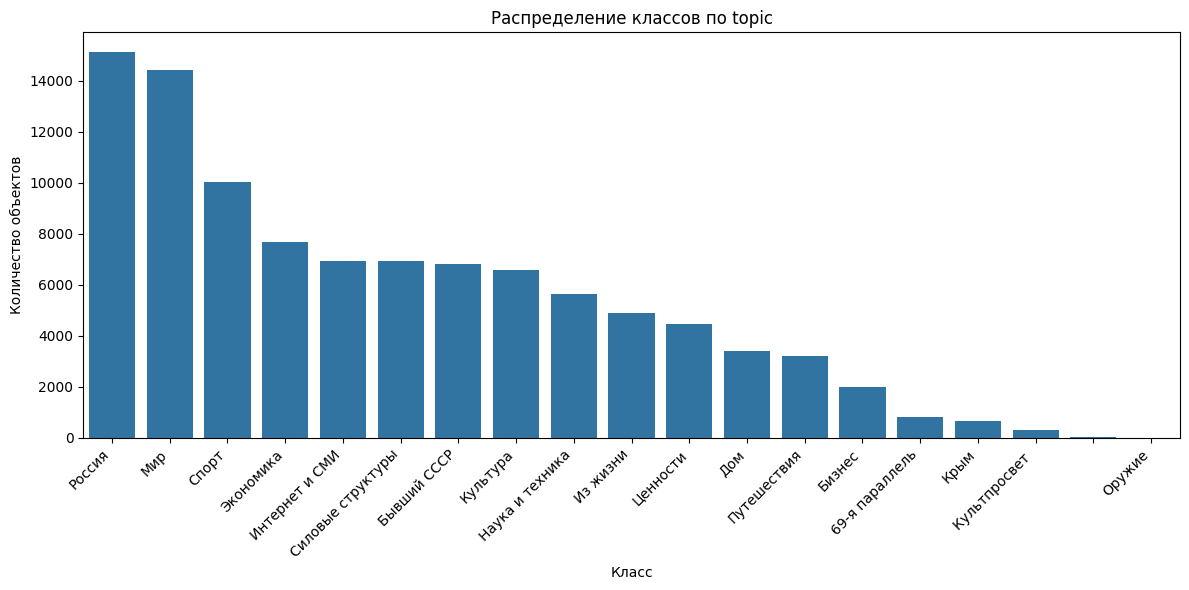

In [71]:
class_counts = df['topic'].value_counts()
class_share = df['topic'].value_counts(normalize=True).mul(100).round(2)

eda_classes = pd.DataFrame({
    'count': class_counts,
    'share_percent': class_share
})

plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Распределение классов по topic')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [72]:
print(eda_classes)

                   count  share_percent
topic                                  
Россия             15151          15.15
Мир                14421          14.42
Спорт              10045          10.04
Экономика           7682           7.68
Интернет и СМИ      6935           6.94
Силовые структуры   6925           6.93
Бывший СССР         6810           6.81
Культура            6578           6.58
Наука и техника     5645           5.64
Из жизни            4903           4.90
Ценности            4480           4.48
Дом                 3408           3.41
Путешествия         3223           3.22
Бизнес              1993           1.99
69-я параллель       815           0.82
Крым                 661           0.66
Культпросвет         307           0.31
                      17           0.02
Оружие                 1           0.00


In [73]:
text_lengths = df['text'].fillna('').str.len()

quality_report = pd.Series({
    'empty_text_after_strip': (df['text'].fillna('').str.strip() == '').sum(),
    'empty_topic_after_strip': (df['topic'].fillna('').str.strip() == '').sum(),
    'duplicate_text_topic': df.duplicated(subset=['text', 'topic']).sum(),
    'min_class_size': df['topic'].value_counts().min(),
    'num_classes': df['topic'].nunique(),
    'min_text_length': text_lengths.min(),
    'max_text_length': text_lengths.max()
})
quality_report

empty_text_after_strip        0
empty_topic_after_strip      17
duplicate_text_topic          3
min_class_size                1
num_classes                  19
min_text_length             212
max_text_length            9282
dtype: int64

Выводы по первичному EDA:
- сильного дисбаланса нет, но есть хвост редких классов;
- есть пустые значения в topic (целевой признак);
- есть точные дубликаты текстов;
- класс с 1 объектом помешает стратифицированному разбиению.

In [ ]:
df_clean = df.copy()

# Нормализуем пробелы и убираем служебные пробелы по краям.
df_clean['text'] = (
    df_clean['text']
    .fillna('')
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
df_clean['topic'] = df_clean['topic'].fillna('').str.strip()

# Удаляем пустые тексты/классы и точные дубликаты.
df_clean = df_clean[(df_clean['text'] != '') & (df_clean['topic'] != '')]
df_clean = df_clean.drop_duplicates(subset=['text', 'topic']).reset_index(drop=True)

# Убираем слишком редкие классы.
min_samples_per_class = 20
valid_topics = df_clean['topic'].value_counts()
valid_topics = valid_topics[valid_topics >= min_samples_per_class].index

df_clean = df_clean[df_clean['topic'].isin(valid_topics)].reset_index(drop=True)

df_clean.shape

(99979, 2)

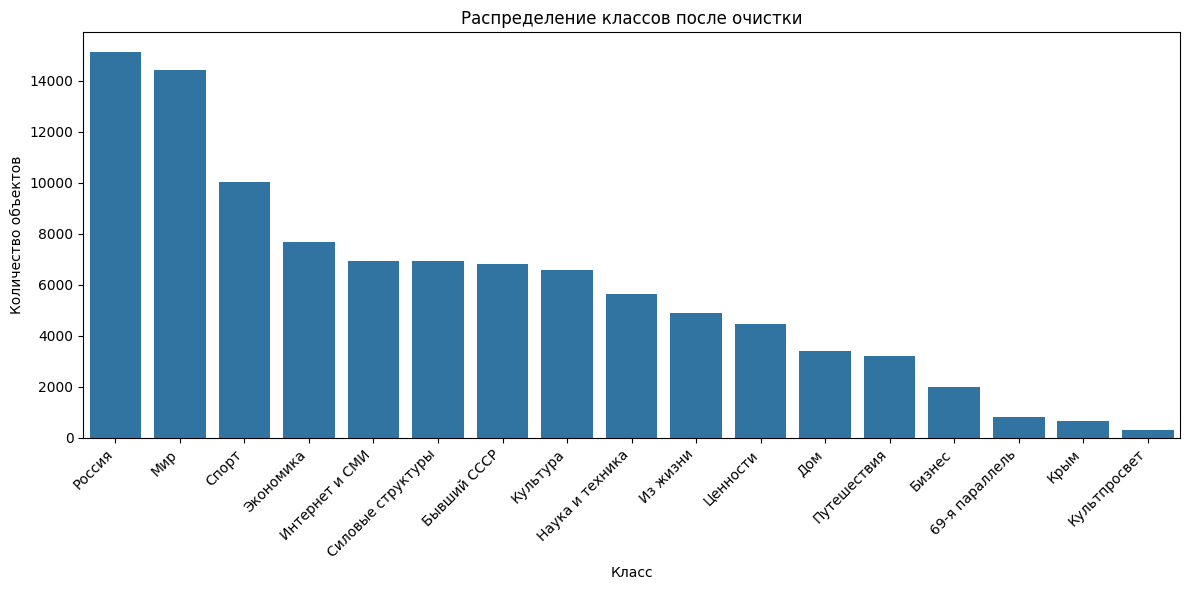

In [79]:
clean_class_counts = df_clean['topic'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=clean_class_counts.index, y=clean_class_counts.values)
plt.title('Распределение классов после очистки')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [80]:
print(clean_class_counts)

topic
Россия               15151
Мир                  14421
Спорт                10045
Экономика             7682
Интернет и СМИ        6935
Силовые структуры     6925
Бывший СССР           6810
Культура              6578
Наука и техника       5644
Из жизни              4903
Ценности              4480
Дом                   3407
Путешествия           3223
Бизнес                1993
69-я параллель         814
Крым                   661
Культпросвет           307
Name: count, dtype: int64


### Preprocessing

- Базовая очистка уже выполнена на этапе `df_clean`.
- Для `CountVectorizer` и `TF-IDF` отдельное ручное удаление пунктуации не обязательно: это покрывается стандартной токенизацией векторизаторов.
- Агрессивное удаление стоп-слов пока не применяем, чтобы не потерять полезные для тематической классификации слова.
- Основная полезная нормализация для русского корпуса здесь лемматизация. Она уменьшает размер словаря и объединяет разные словоформы.
- Поэтому дальше используем умеренную предобработку: `lowercase`, замена `ё -> е`, токенизация, фильтрация до буквенных токенов и лемматизация.

In [ ]:
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=200000)
def lemmatize_token(token: str) -> str:
    return morph.parse(token)[0].normal_form


def preprocess_text(text: str) -> str:
    text = text.lower().replace('ё', 'е')
    lemmas = []

    for token in razdel.tokenize(text):
        token_text = token.text.strip('-')
        if not token_text:
            continue
        if not re.fullmatch(r'[а-я-]+', token_text):
            continue
        lemmas.append(lemmatize_token(token_text))

    return ' '.join(lemmas)


df_prepared = df_clean.copy()
df_prepared['text_preprocessed'] = [preprocess_text(text) for text in tqdm.tqdm(df_prepared['text'])]

df_prepared[['text', 'text_preprocessed']].head(3)

100%|██████████| 99979/99979 [01:09<00:00, 1433.27it/s]


,text,text_preprocessed
0,Вице-премьер по социальным вопросам Татьяна Го...,вице-премьер по социальный вопрос татьяна голи...
1,Австрийские правоохранительные органы не предс...,австрийский правоохранительный орган не предст...
2,Сотрудники социальной сети Instagram проанализ...,сотрудник социальный сеть проанализировать пос...


In [83]:
train_df, temp_df = train_test_split(
    df_prepared,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=df_prepared['topic']
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=temp_df['topic']
)

print('train shape:', train_df.shape)
print('valid shape:', valid_df.shape)
print('test shape:', test_df.shape)

train shape: (59987, 3)
valid shape: (19996, 3)
test shape: (19996, 3)


In [119]:
X_train = train_df['text_preprocessed']
y_train = train_df['topic']
X_val = valid_df['text_preprocessed']
y_val = valid_df['topic']
X_test = test_df['text_preprocessed']
y_test = test_df['topic']

Одна общая функция оценки для baseline и последующих моделей.

In [104]:
def evaluate_text_model(model_name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_proba = model.predict_proba(X_val)
    y_val_bin = label_binarize(y_val, classes=model.classes_)

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_val, val_pred),
        'roc_auc_macro': roc_auc_score(y_val, val_proba, average='macro', multi_class='ovr'),
        'pr_auc_macro': average_precision_score(y_val_bin, val_proba, average='macro'),
    }

### Baseline

Возьмем Dummy модель, предсказывающую самый частотный класс

In [105]:
baseline_model = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)

baseline_results = pd.DataFrame([
    evaluate_text_model('DummyClassifier', baseline_model, X_train, y_train, X_val, y_val)
]).round(4)

baseline_results

,model,accuracy,roc_auc_macro,pr_auc_macro
0,DummyClassifier,0.1516,0.5,0.0588


### LogisticRegression

Сравнение `LogisticRegression` с `CountVectorizer` и `TfidfVectorizer`.

In [113]:
# LogisticRegression с двумя способами векторизации
models = {
    'LogReg + CountVectorizer': Pipeline([
        ('vectorizer', CountVectorizer(max_features=MAX_FEATURES)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'LogReg + TfidfVectorizer': Pipeline([
        ('vectorizer', TfidfVectorizer(max_features=MAX_FEATURES)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
}

logreg_results = pd.DataFrame([
    evaluate_text_model(model_name, model, X_train, y_train, X_val, y_val)
    for model_name, model in models.items()
]).sort_values(by='accuracy', ascending=False).reset_index(drop=True).round(4)

logreg_results

,model,accuracy,roc_auc_macro,pr_auc_macro
0,LogReg + TfidfVectorizer,0.8219,0.9867,0.8296
1,LogReg + CountVectorizer,0.7936,0.9769,0.7908


### Hyperparameter tuning

Подбор гиперпараметров только для `TfidfVectorizer` и `LogisticRegression` с помощью `GridSearchCV` на `train`-выборке.

In [ ]:
# Упрощенный тюнинг, чтобы кросс-валидация считалась быстрее
cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)

tuning_pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

param_grid = {
    'vectorizer__ngram_range': [(1, 1), (1, 2)],
    'vectorizer__min_df': [3, 5],
    'classifier__C': [1.0, 3.0],
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

In [116]:
best_params = grid_search.best_params_.copy()
best_params['vectorizer'] = 'TfidfVectorizer'

cv_results = pd.DataFrame(grid_search.cv_results_)
cv_summary = cv_results[[
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_vectorizer__ngram_range',
    'param_vectorizer__min_df',
    'param_classifier__C',
]].copy()
cv_summary = cv_summary.sort_values(by=['rank_test_score', 'mean_test_score'], ascending=[True, False]).reset_index(drop=True)

best_model_results = pd.DataFrame([
    evaluate_text_model('Best CV model', grid_search.best_estimator_, X_train, y_train, X_val, y_val)
]).round(4)

print(f"Best CV accuracy: {grid_search.best_score_:.4f}")
display(pd.DataFrame([best_params]))
display(cv_summary.head(10).round(4))
best_model_results

Best CV accuracy: 0.8351


,classifier__C,vectorizer__min_df,vectorizer__ngram_range,vectorizer
0,3.0,5,"(1, 2)",TfidfVectorizer


,rank_test_score,mean_test_score,std_test_score,param_vectorizer__ngram_range,param_vectorizer__min_df,param_classifier__C
0,1,0.8351,0.0007,"(1, 2)",5,3.0
1,2,0.8339,0.0008,"(1, 2)",3,3.0
2,3,0.8295,0.0010,"(1, 1)",3,3.0
3,4,0.8295,0.0014,"(1, 1)",5,3.0
4,5,0.8173,0.0003,"(1, 1)",5,1.0
5,6,0.8171,0.0014,"(1, 2)",5,1.0
6,7,0.8171,0.0006,"(1, 1)",3,1.0
7,8,0.8145,0.0015,"(1, 2)",3,1.0


,model,accuracy,roc_auc_macro,pr_auc_macro
0,Best CV model,0.8533,0.9911,0.8779


### Hold-out sample estimation

Оценка лучшего пайплайна на отложенной `test`-выборке. Для финальной оценки модель дообучается на объединении `train + valid`, после чего проверяется на `test`.

In [123]:
best_model = grid_search.best_estimator_
test_pred = best_model.predict(X_test)
test_proba = best_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=best_model.classes_)

test_results = pd.DataFrame([
    {
        'accuracy': accuracy_score(y_test, test_pred),
        'roc_auc_macro': roc_auc_score(y_test, test_proba, average='macro', multi_class='ovr'),
        'pr_auc_macro': average_precision_score(y_test_bin, test_proba, average='macro'),
    }
]).round(4)

test_results

,accuracy,roc_auc_macro,pr_auc_macro
0,0.8553,0.991,0.8825


### Error Analysis

Таблица с самыми частыми парами ошибок: истинный класс и класс, который модель предсказала вместо него.

In [131]:
error_analysis_df = pd.DataFrame({
    'true_label': y_test.reset_index(drop=True),
    'pred_label': pd.Series(test_pred),
})

confusion_pairs = (
    error_analysis_df[error_analysis_df['true_label'] != error_analysis_df['pred_label']]
    .groupby(['true_label', 'pred_label'])
    .size()
    .reset_index(name='count')
    .sort_values(by='count', ascending=False)
    .reset_index(drop=True)
)

top_confusion_pairs = confusion_pairs.head(10)
top_confusion_pairs

,true_label,pred_label,count
0,Силовые структуры,Россия,185
1,Бизнес,Экономика,135
2,Россия,Силовые структуры,132
3,Россия,Мир,80
4,Силовые структуры,Мир,78
5,Из жизни,Мир,69
6,Мир,Россия,65
7,Бывший СССР,Россия,63
8,Дом,Россия,59
9,Интернет и СМИ,Мир,58


In [135]:
valid_accuracy = float(best_model_results.loc[0, 'accuracy'])
test_accuracy = float(test_results.loc[0, 'accuracy'])
generalization_gap = round(valid_accuracy - test_accuracy, 4)

most_confused_true_label = top_confusion_pairs.loc[0, 'true_label']
most_confused_pred_label = top_confusion_pairs.loc[0, 'pred_label']
most_confused_count = int(top_confusion_pairs.loc[0, 'count'])

conclusions_summary = {
    'valid_accuracy': round(valid_accuracy, 4),
    'test_accuracy': round(test_accuracy, 4),
    'generalization_gap': generalization_gap,
    'most_confused_true_label': most_confused_true_label,
    'most_confused_pred_label': most_confused_pred_label,
    'most_confused_count': most_confused_count,
}

pd.DataFrame([conclusions_summary])

,valid_accuracy,test_accuracy,generalization_gap,most_confused_true_label,most_confused_pred_label,most_confused_count
0,0.8533,0.8553,-0.002,Силовые структуры,Россия,185


### Conclusions

1. Лучшая модель на `test` дала `accuracy = 0.8553`.
2. Разрыв между `valid` и `test` небольшой, модель обобщает достаточно стабильно.
3. Чаще всего модель путает класс `Силовые структуры` с классом `Россия` (`185` случаев).
4. Для дальнейшего улучшения стоит смотреть на классы с наибольшим кол-вом ошибок.